In [81]:
import matplotlib.pyplot as plt 
import json 
import numpy as np 
import pandas as pd
import os 
from utils import extract_subprotocols_with_idxs, extract_subprotocol_data
from analysis_scripts import (transform_CVs_to_ECSA, transform_CVs_to_stability_metrics, transform_EIS_data_to_dict)
import pandas as pd 
import numpy as np 
from plotting_tools import extract_ECSA

# Investigating ECSA

In [82]:
from scipy.optimize import minimize
def get_interpolation_EIS(Re_Z, Im_Z):

    Re_Z = np.asarray(Re_Z, dtype=float).flatten()
    Im_Z = np.asarray(Im_Z, dtype=float).flatten()

    mask = np.isfinite(Re_Z) & np.isfinite(Im_Z)

    Re_Z = Re_Z[mask]
    Im_Z = Im_Z[mask]

    mask = Re_Z < 1.1

    Re_Z = Re_Z[mask]
    Im_Z = Im_Z[mask]

    crossing = np.where(np.diff(np.sign(Im_Z)) != 0)[0]

    if len(crossing) == 0:
        print("NO CROSSING")
        return np.nan

    i = crossing[0]

    x1, x2 = Re_Z[i], Re_Z[i+1]
    y1, y2 = Im_Z[i], Im_Z[i+1]

    R_ohm = x1 - y1*(x2-x1)/(y2-y1)

    return R_ohm

scan_idx = -1

ECSAs_initial = []
ECSAs_final = []
activities_initial = []
activities_final = []
folderpath_main = "/Volumes/Elements/Random experiments baseline"
results_dict = {}

for folderpath in os.listdir(folderpath_main):
    if "exp" in folderpath:
        for file in os.listdir(os.path.join(folderpath_main, folderpath)):
            if "parameter" in file: # Parameter dictionary
                parameter_dict_path = os.path.join(folderpath_main, folderpath, file)
            elif "Testing_data" in file: # The testing data
                if file.endswith(".csv"):
                    df_data_path = os.path.join(folderpath_main, folderpath, file)
                    df = pd.read_csv(df_data_path)
            elif "calibration" in file:
                if file.endswith(".csv"):
                    CV_calibration_file = os.path.join(folderpath_main, folderpath, file)
            
            try:
                with open(parameter_dict_path, "r") as f:
                    parameter_dict = json.load(f)
            except Exception as e:
                print(e)
                continue

        subprotocol_idxs = extract_subprotocols_with_idxs(parameter_dict_path)

        data_stability_scans = extract_subprotocol_data(df=df, 
                                subprotocol_idxs=subprotocol_idxs, 
                                selected_comment="Stability scans NiMo")

        data_ECSA_before = extract_subprotocol_data(df=df, 
                                subprotocol_idxs=subprotocol_idxs, 
                                selected_comment="ECSA scans NiMo before cycling") # What comment did we give the protocol 

        data_ECSA_after = extract_subprotocol_data(df=df, 
                                subprotocol_idxs=subprotocol_idxs, 
                                selected_comment="ECSA scans NiMo after cycling")

        data_GEIS_initial = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Initial GEIS",
            selected_protocol="GEIS"
        )

        data_GEIS_final = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Final GEIS",
            selected_protocol="GEIS"
        )

        
        EIS_dict = transform_EIS_data_to_dict(
            EIS_measurements=[data_GEIS_initial, data_GEIS_final],
            names=["GEIS initial", "GEIS final"],
            plot_EIS=False
        )
        
        IR_correction = get_interpolation_EIS(Re_Z=EIS_dict["GEIS initial"]["Re_Z"], 
                                              Im_Z = EIS_dict["GEIS initial"]["Im_Z"])
                                              
        Stability_dict = transform_CVs_to_stability_metrics(stability_cycling_CVs=data_stability_scans, 
                            current_densities = [1, 10, 100], 
                            IR_correction = IR_correction)

        

        ECSA_dict = transform_CVs_to_ECSA(CV_series=[data_ECSA_before, data_ECSA_after], 
                            names = ["Cap current init [mA]", "Cap current final [mA]"], 
                            plot_certain_scan_rates=[2, 5, 10, 20, 40], 
                            plot_CVs=False)
        
        
        #IR_correction = get_IR_correction(Re_Z=np.array(EIS_dict["GEIS initial"]["Re_Z"]), 
        #                                            Im_Z=np.array(EIS_dict["GEIS initial"]["Im_Z"]), 
        #                                            X_MIN=0.2, X_MAX=0.8)
        print(IR_correction)
        ECSA_initial, ECSA_final = extract_ECSA(ECSA_dict=ECSA_dict, plot=False)

        initial_OP_10 = Stability_dict['Overpotentials at 10 mA/cm2'][1]
        final_OP_10 = Stability_dict['Overpotentials at 10 mA/cm2'][-1]

        initial_OP_100 = Stability_dict['Overpotentials at 100 mA/cm2'][1]
        final_OP_100 = Stability_dict['Overpotentials at 100 mA/cm2'][-1]

        results_dict[folderpath] = {
            "ECSA_initial": ECSA_initial,
            "ECSA_final": ECSA_final,
            "overpotentials": Stability_dict
        }
        



'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
0.6841435505001388
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
0.432426066962588
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
0.727116179765469
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
0.47328352164831944
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
NO CROSSING
nan
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
0.4405550368413436
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
0.3328517103829827
'<' not supported between instances of 'list' and 'float'
'

/Volumes/Elements/Random experiments baseline/Reproducibility/04_03_2026_18_18__exp_14/Testing_data_04_03_2026_18_18__exp_14.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'


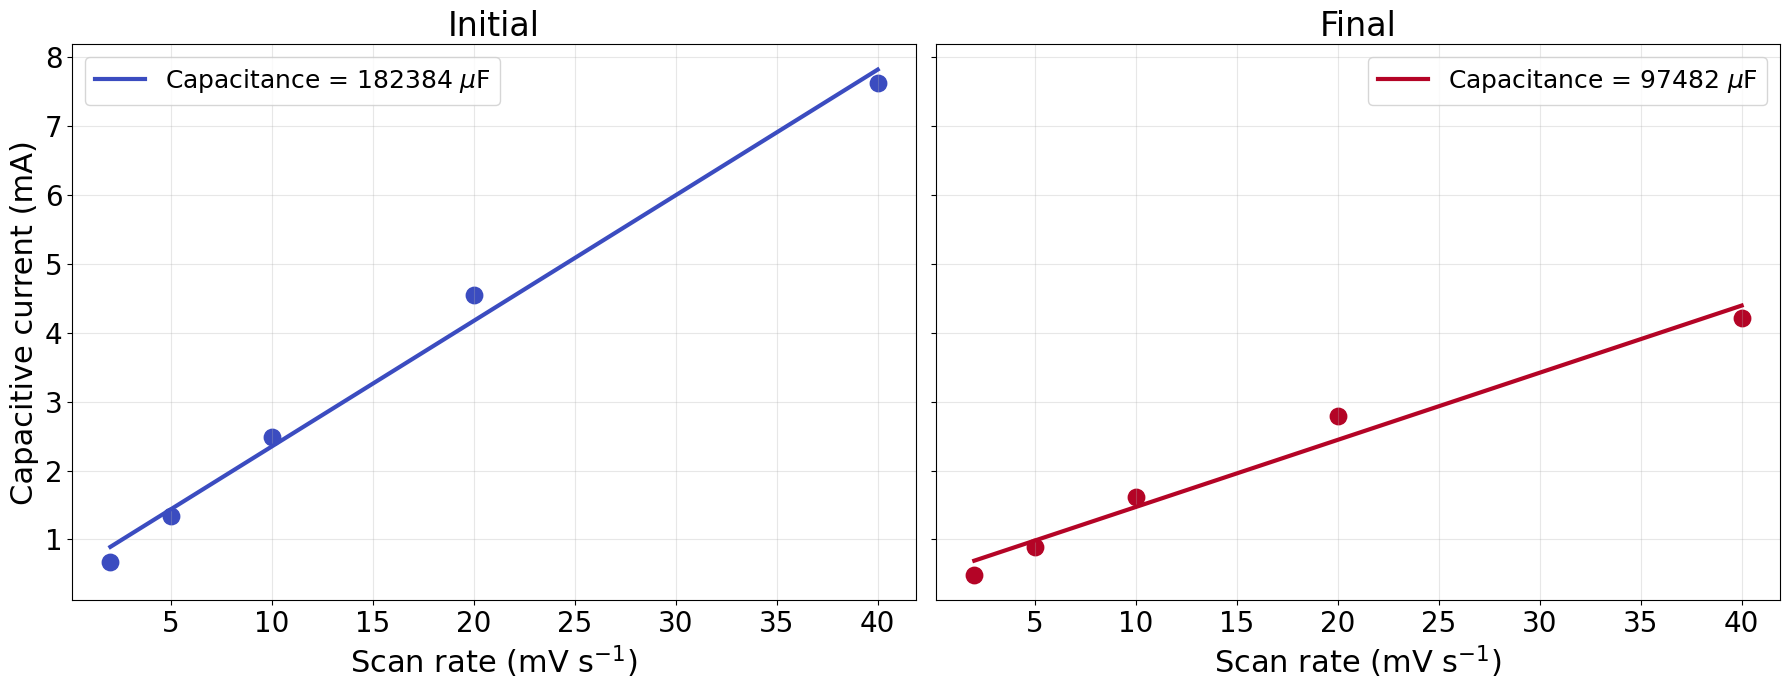

/Volumes/Elements/Random experiments baseline/Reproducibility/04_03_2026_20_09__exp_15/Testing_data_04_03_2026_20_09__exp_15.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
index 0 is out of bounds for axis 0 with size 0
/Volumes/Elements/Random experiments baseline/Reproducibility/04_03_2026_21_58__exp_16/Testing_data_04_03_2026_21_58__exp_16.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'


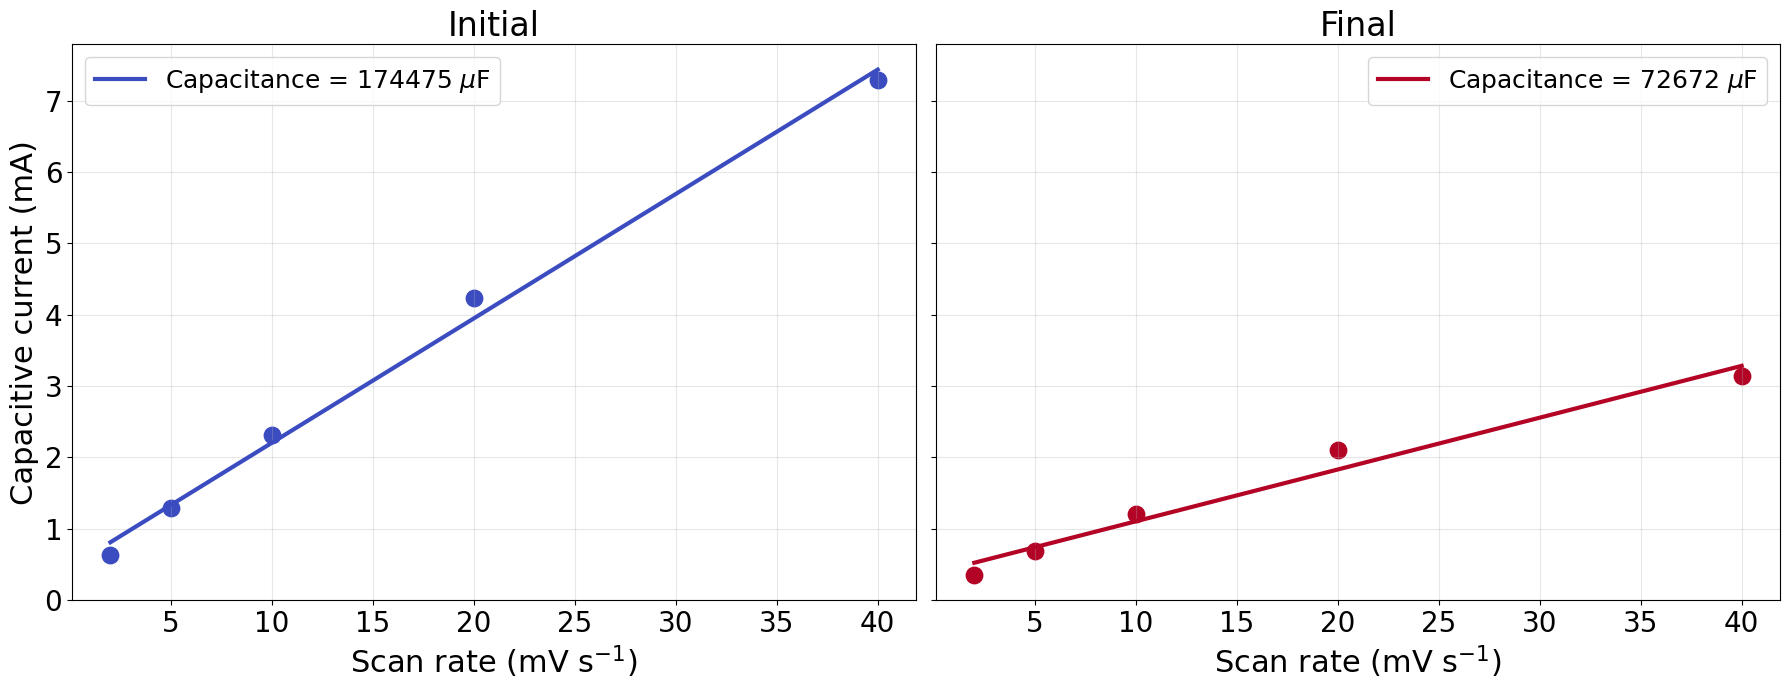

/Volumes/Elements/Random experiments baseline/Reproducibility/04_03_2026_23_46__exp_17/Testing_data_04_03_2026_23_46__exp_17.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'
index 0 is out of bounds for axis 0 with size 0
/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_01_37__exp_18/Testing_data_05_03_2026_01_37__exp_18.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'


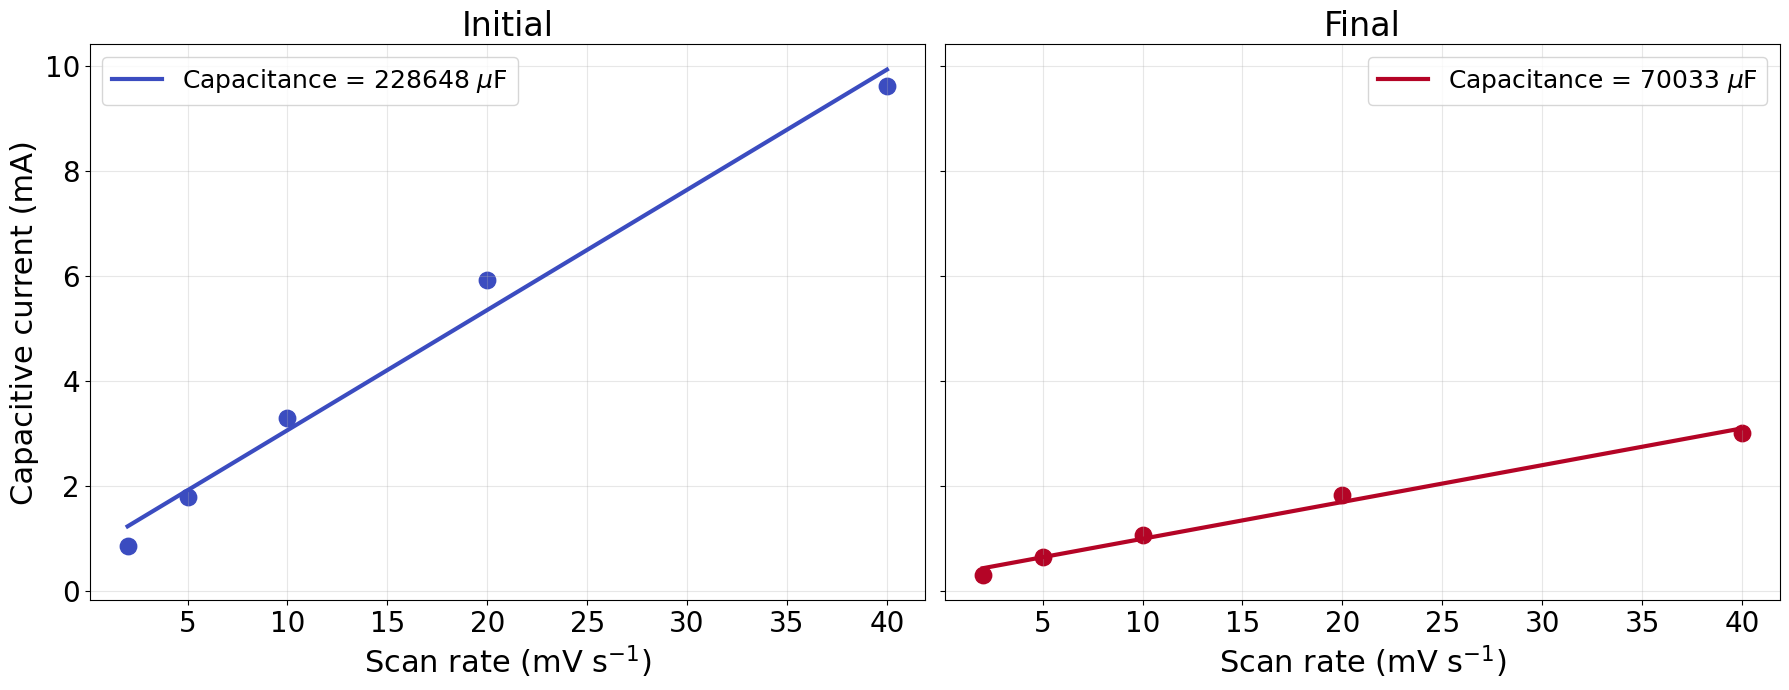

/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_03_22__exp_19/Testing_data_05_03_2026_03_22__exp_19.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'


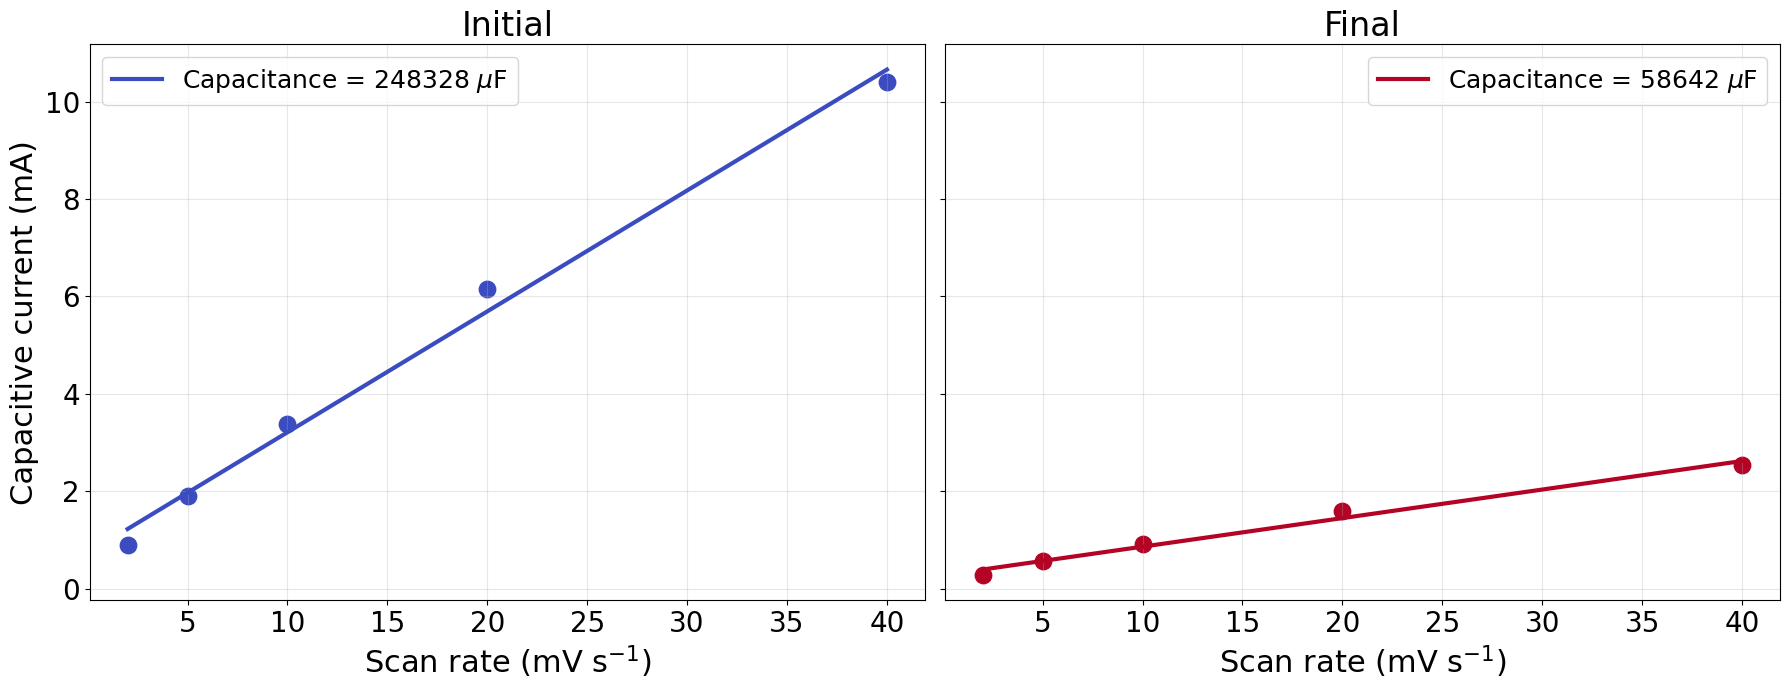

/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_05_05__exp_20/Testing_data_05_03_2026_05_05__exp_20.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'


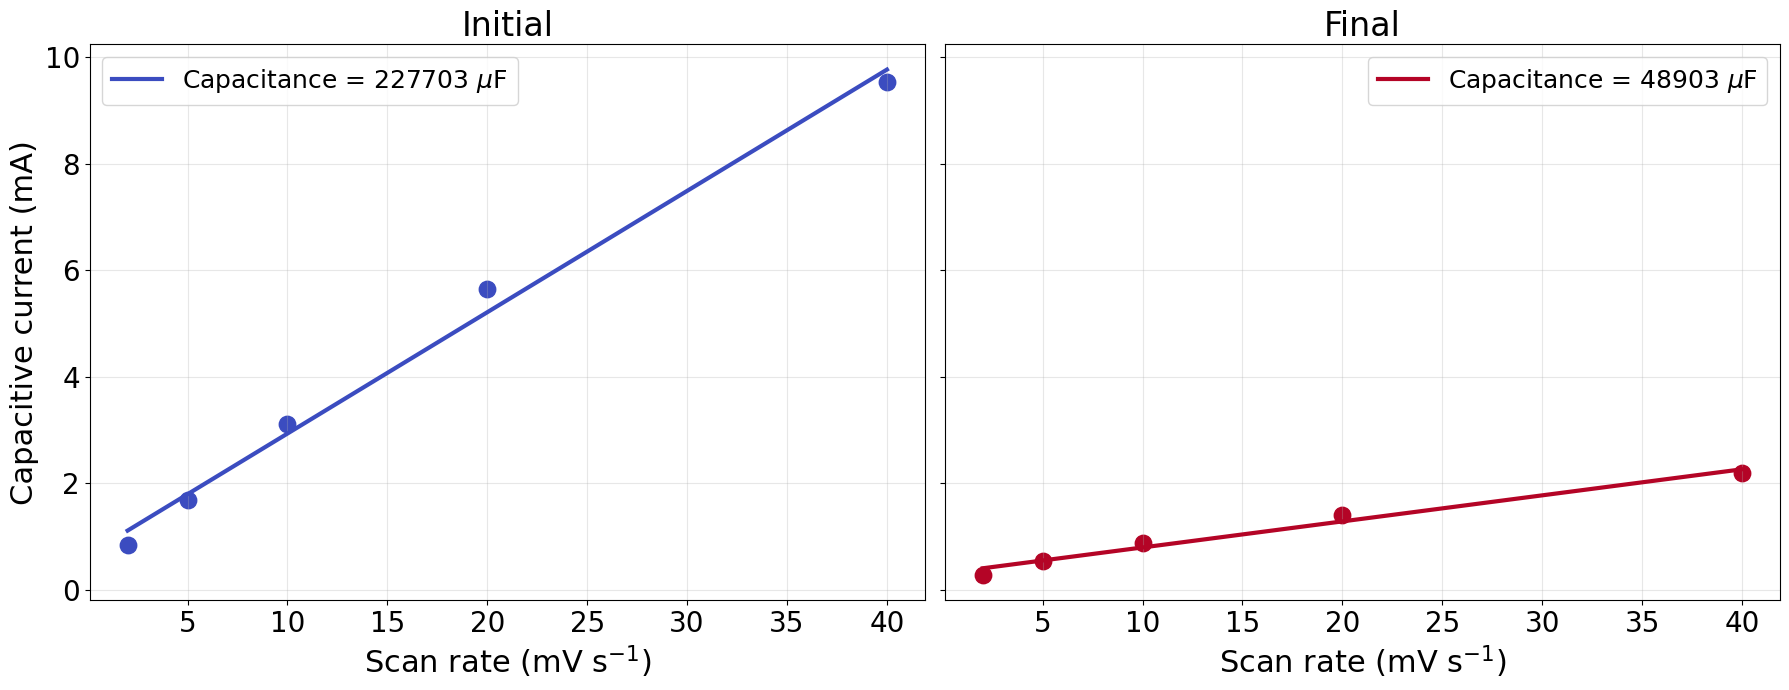

/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_06_49__exp_21/Testing_data_05_03_2026_06_49__exp_21.csv
'<' not supported between instances of 'list' and 'float'
'<' not supported between instances of 'list' and 'float'


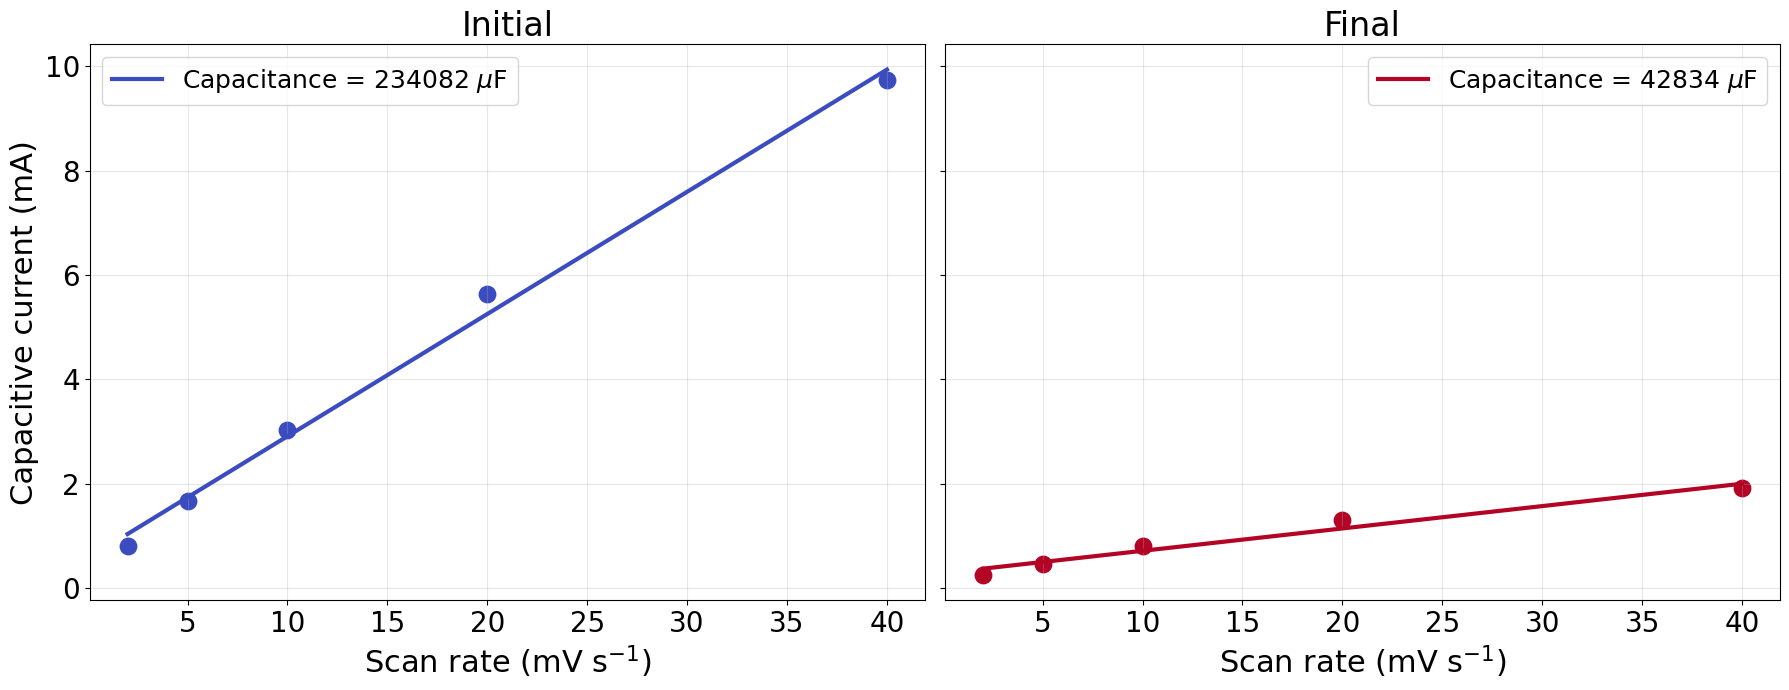

/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_08_38__exp_22/Testing_data_05_03_2026_08_38__exp_22.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_10_14__exp_23/Testing_data_05_03_2026_10_14__exp_23.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_11_49__exp_24/Testing_data_05_03_2026_11_49__exp_24.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/05_03_2026_13_26__exp_25/Testing_data_05_03_2026_13_26__exp_25.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/24_02_2026_16_10__exp_2/Testing_data_24_02_2026_16_10__exp_2.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/24_02_2026_18_01__exp_3/Testing_data_24_02_2026_18_01__exp_3.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/24_02_2026_19_50__exp_4/Testing_data_24_02_2026_19_50__exp_4.csv
/Volumes/Elements/Random experiments baseline/Reproducibility/24_02_2026_21_39__exp_5/Testing_data_24_0

In [86]:
groups_69M = {}
folder_reproducibility = "/Volumes/Elements/Random experiments baseline/Reproducibility"
######## Adding data from reproducibility runs:
def get_IR_correction(Re_Z, Im_Z, X_MIN = 0.6, X_MAX = 1.0):
        
    Y_MIN, Y_MAX = -0.1, 0.1     # -Im(Z) window

    mask = (
            (Re_Z >= X_MIN) & (Re_Z <= X_MAX) &
            (Im_Z >= Y_MIN) & (Im_Z <= Y_MAX)
        )
    
    x = Re_Z[mask]
    y = Im_Z[mask]

    sign_change = np.where(np.diff(np.sign(y)))[0]
    idx = sign_change[0]

    # linear interpolation
    x1, x2 = x[idx], x[idx+1]
    y1, y2 = y[idx], y[idx+1]

    x_cross = x1 - y1 * (x2 - x1) / (y2 - y1)

    return x_cross

for subfolder in os.listdir(folder_reproducibility):
    try:
        if "_exp" not in subfolder:
            continue

        folderpath = os.path.join(folder_reproducibility, subfolder)
        parameter_dict_path = None
        df_data_path = None
        CV_calibration_file = None
        
        # Locate files
        for file in os.listdir(folderpath):
            if "parameter" in file and file.endswith(".json"):
                parameter_dict_path = os.path.join(folderpath, file)
            elif "Testing_data" in file and file.endswith(".csv"):
                df_data_path = os.path.join(folderpath, file)
            elif "calibration" in file and file.endswith(".csv"):
                CV_calibration_file = os.path.join(folderpath, file)

        if parameter_dict_path is None or df_data_path is None:
            continue  # skip if essential files are missing

        # Load parameter dict
        with open(parameter_dict_path, "r") as f:
            parameter_dict = json.load(f)

        print(df_data_path)
        exp_name = [key for key in parameter_dict if key.endswith(".csv")][0]
        dep_time = parameter_dict[exp_name]["Deposition time [s]"]
        timestamp_str = parameter_dict["timestamp"]
        testing_conc = parameter_dict[exp_name]["Stock solutions"]["Pump 1"]["Contents"]["KOH"]["Concentration [mol/L]"]
        if float(testing_conc) < 6:
            continue
        # Read experimental data
        df = pd.read_csv(df_data_path)
        subprotocol_idxs = extract_subprotocols_with_idxs(parameter_dict_path)

        # Extract subprotocols
        data_stability_scans = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Stability scans NiMo"
        )

        data_ECSA_before = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="ECSA scans NiMo before cycling"
        )

        data_ECSA_after = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="ECSA scans NiMo after cycling"
        )

        ECSA_dict_before_after = transform_CVs_to_ECSA(
            [data_ECSA_before, data_ECSA_after],
            names=["Cap current init [mA]", "Cap current final [mA]"],
            plot_CVs=False
        )
        ECSA_dict = transform_CVs_to_ECSA(CV_series=[data_ECSA_before, data_ECSA_after], 
                            names = ["Cap current init [mA]", "Cap current final [mA]"], 
                            plot_certain_scan_rates=[2, 5, 10, 20, 40], 
                            plot_CVs=False)

        data_GEIS_initial = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Initial GEIS",
            selected_protocol="GEIS"
        )

        data_GEIS_final = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Final GEIS",
            selected_protocol="GEIS"
        )

        EIS_dict = transform_EIS_data_to_dict(
            EIS_measurements=[data_GEIS_initial, data_GEIS_final],
            names=["GEIS initial", "GEIS final"],
            plot_EIS=False
        )
        
        IR_correction = EIS_dict["GEIS initial"]["IR correction"]
       

        if IR_correction == 0:
            if float(testing_conc) > 1:

                IR_correction = get_IR_correction(Re_Z=np.array(EIS_dict["GEIS initial"]["Re_Z"]), 
                                                    Im_Z=np.array(EIS_dict["GEIS initial"]["Im_Z"]), 
                                                    X_MIN=0.4, X_MAX=0.6)
            else:
                IR_correction = get_IR_correction(Re_Z=np.array(EIS_dict["GEIS initial"]["Re_Z"]), 
                                                    Im_Z=np.array(EIS_dict["GEIS initial"]["Im_Z"]))
        
        Stability_dict = transform_CVs_to_stability_metrics(
            stability_cycling_CVs=data_stability_scans,
            current_densities=[1, 10, 100],
            IR_correction=IR_correction
        )
        
        ECSA_initial, ECSA_final = extract_ECSA(ECSA_dict=ECSA_dict, plot=True)

        exp_data = {"ECSA_initial": ECSA_initial,
                "ECSA_final": ECSA_final,
                "overpotentials": Stability_dict}
        if dep_time not in groups_69M:
            groups_69M[dep_time] = []
        
        groups_69M[dep_time].append(exp_data)
    except Exception as e:
        print(e)
        continue
    

# Plotting activity vs ECSA

[np.float64(0.23469017299186307), np.float64(0.1784297374862911)] THIOS IS IT


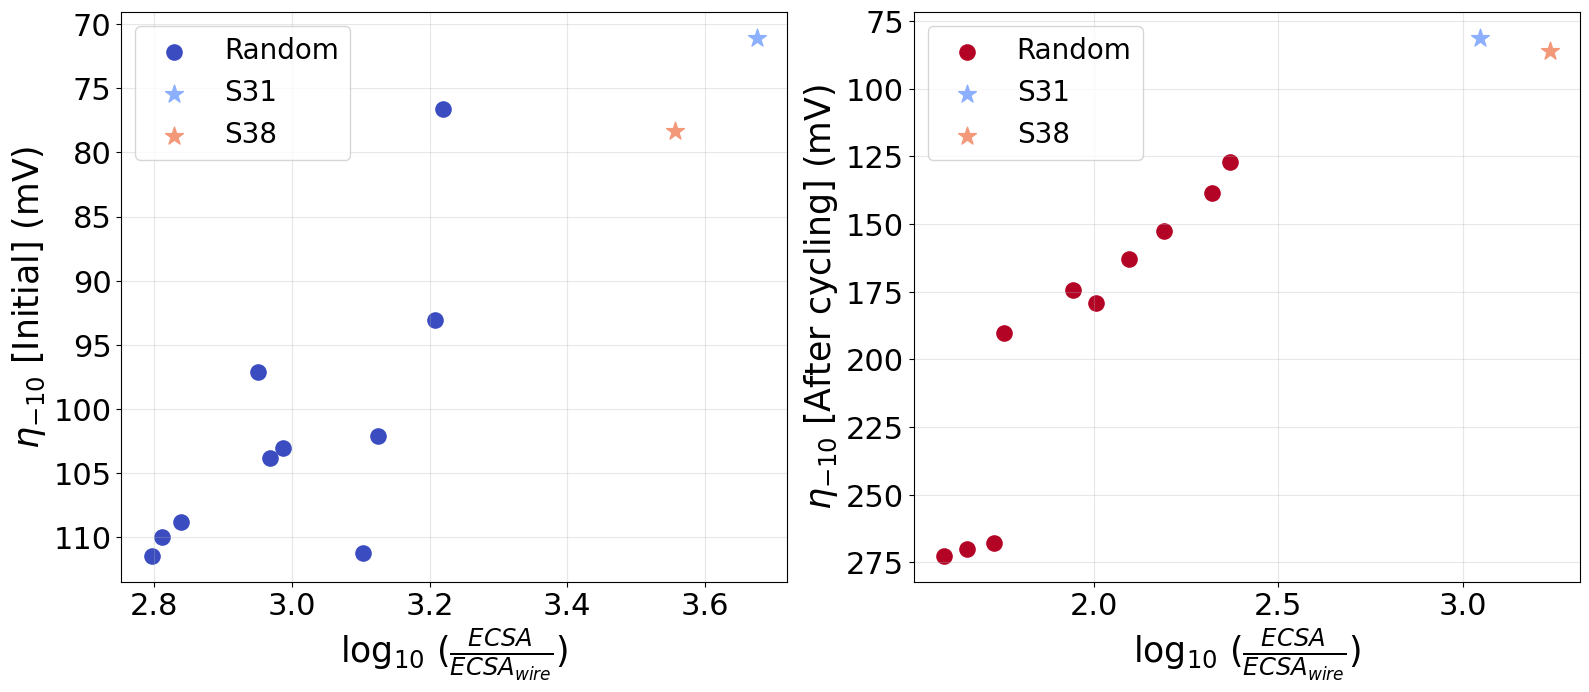

In [105]:
cmap = plt.get_cmap("coolwarm")
bare_nickel_wire_ECSA = 49.5 * 10 ** -6 # Measured bare wire nickel ECSA 
blue = cmap(0.0)
red = cmap(1.0)



ECSAs_initial = np.array([results_dict[x]["ECSA_initial"] / bare_nickel_wire_ECSA for x in results_dict])
ECSAs_final = np.array([results_dict[x]["ECSA_final"] / bare_nickel_wire_ECSA for x in results_dict])

OP10_initial = np.array([results_dict[x]["overpotentials"]['Overpotentials at 10 mA/cm2'][1] for x in results_dict])
OP10_final = np.array([results_dict[x]["overpotentials"]['Overpotentials at 10 mA/cm2'][-1] for x in results_dict])


# Average experiments with identical deposition time in 69M
ECSA_69M_initial = []
ECSA_69M_final = []
OP10_69M_initial = []
OP10_69M_final = []
OP100_69M_initial = []
OP100_69M_final = []

for dep_time in sorted(groups_69M.keys()):
    
    experiments = groups_69M[dep_time]

    ECSA_69M_initial.append(np.mean([x["ECSA_initial"]  for x in experiments]))
    ECSA_69M_final.append(np.mean([x["ECSA_final"] for x in experiments]))

    OP10_69M_initial.append(np.mean([x["overpotentials"]['Overpotentials at 10 mA/cm2'][1] for x in experiments]))
    OP10_69M_final.append(np.mean([x["overpotentials"]['Overpotentials at 10 mA/cm2'][-1] for x in experiments]))


print(ECSA_69M_initial, "THIOS IS IT")
ECSA_69M_initial = np.array(ECSA_69M_initial) / bare_nickel_wire_ECSA
ECSA_69M_final = np.array(ECSA_69M_final) / bare_nickel_wire_ECSA

OP10_69M_initial = np.array(OP10_69M_initial)
OP10_69M_final = np.array(OP10_69M_final)



# Top 10 random samples based on initial 10 mA cm-2 performance
top_idx = np.argsort(OP10_initial)[::-1][:11]

log_ECSA_initial = np.log10(ECSAs_initial[top_idx])
log_ECSA_final = np.log10(ECSAs_final[top_idx])

OP10_initial_top = OP10_initial[top_idx]
OP10_final_top = OP10_final[top_idx]

fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharex=False, sharey=False)

# Define separate colors from coolwarm
blue_69M = cmap(0.25)
red_69M = cmap(0.75)

# Before - 10 mA/cm2
ax[0].scatter(log_ECSA_initial, np.abs(OP10_initial_top), s=120, color=blue, label="Random")

ax[0].scatter(np.log10(ECSA_69M_initial[0]), np.abs(OP10_69M_initial[0]), 
              s=180, color=blue_69M, marker="*", label="S31")

ax[0].scatter(np.log10(ECSA_69M_initial[1]), np.abs(OP10_69M_initial[1]), 
              s=180, color=red_69M, marker="*", label="S38")

ax[0].set_ylabel(r"$\eta_{-10}$ [Initial] (mV)", fontsize=25)
ax[0].set_xlabel(r"log$_{10}$ ($\frac{ECSA}{ECSA_{wire}})$", fontsize=25)
ax[0].invert_yaxis()


# After - 10 mA/cm2
ax[1].scatter(log_ECSA_final, np.abs(OP10_final_top), s=120, color=red, label="Random")

ax[1].scatter(np.log10(ECSA_69M_final[0]), np.abs(OP10_69M_final[0]), 
              s=180, color=blue_69M, marker="*", label="S31")

ax[1].scatter(np.log10(ECSA_69M_final[1]), np.abs(OP10_69M_final[1]), 
              s=180, color=red_69M, marker="*", label="S38")

ax[1].set_ylabel(r"$\eta_{-10}$ [After cycling] (mV)", fontsize=25)
ax[1].set_xlabel(r"log$_{10}$ ($\frac{ECSA}{ECSA_{wire}})$", fontsize=25)
ax[1].invert_yaxis()

for a in ax:
    a.tick_params(axis="both", labelsize=22)
    a.grid(alpha=0.3)
    a.legend(fontsize=20)

plt.tight_layout()
plt.show()

# Normalize by nickel wire

# Change in ECSA

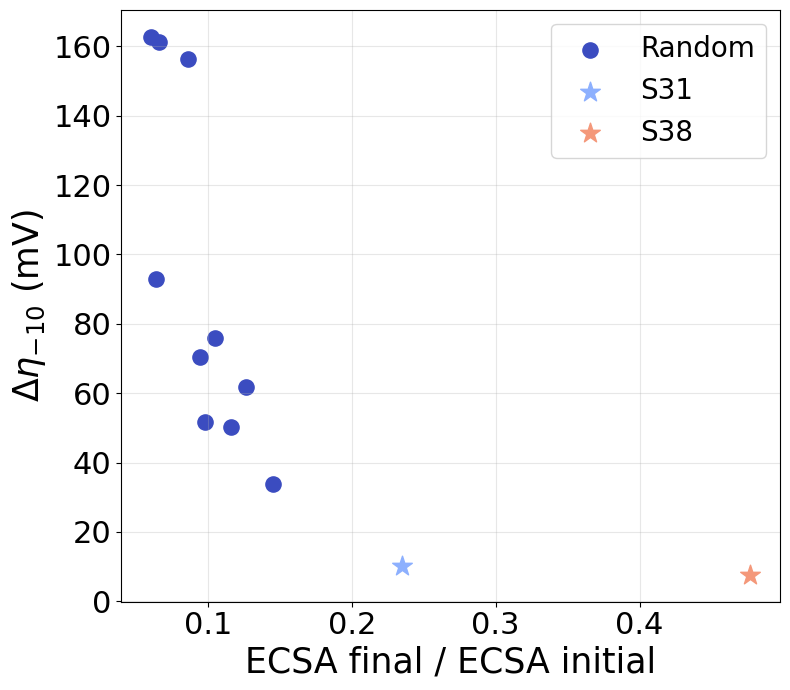

In [111]:
cmap = plt.get_cmap("coolwarm")

blue = cmap(0.0)
red = cmap(1.0)

# Top 11 random samples based on initial 10 mA cm-2 performance
top_idx = np.argsort(OP10_initial)[::-1][:11]

# Ratio change for random samples
ECSA_change = ECSAs_final / ECSAs_initial
ECSA_change_top = ECSA_change[top_idx]

OP10_initial_abs = np.abs(OP10_initial)
OP10_final_abs = np.abs(OP10_final)

OP10_change = OP10_final_abs - OP10_initial_abs
OP10_change_top = OP10_change[top_idx]


# Ratio change for 69M samples
ECSA_69M_change = ECSA_69M_final / ECSA_69M_initial

OP10_69M_initial_abs = np.abs(OP10_69M_initial)
OP10_69M_final_abs = np.abs(OP10_69M_final)

OP10_69M_change = OP10_69M_final_abs - OP10_69M_initial_abs


fig, ax = plt.subplots(figsize=(8, 7))

blue_69M = cmap(0.25)
red_69M = cmap(0.75)


# Top random samples
ax.scatter(ECSA_change_top, OP10_change_top, s=120, color=blue, label="Random")


# 69M samples
ax.scatter(ECSA_69M_change[0], OP10_69M_change[0], 
           s=220, color=blue_69M, marker="*", label="S31")

ax.scatter(ECSA_69M_change[1], OP10_69M_change[1], 
           s=220, color=red_69M, marker="*", label="S38")


ax.set_xlabel("ECSA final / ECSA initial", fontsize=25)
ax.set_ylabel(r"$\Delta \eta_{-10}$ (mV)", fontsize=25)


ax.tick_params(axis="both", labelsize=22)
ax.grid(alpha=0.3)
ax.legend(fontsize=20)


plt.tight_layout()
plt.show()

# Normalizing activity by ECSA

In [ ]:
initial_OP = Stability_dict['Overpotentials at 10 mA/cm2'][0]
final_OP = Stability_dict['Overpotentials at 10 mA/cm2'][-1]



f